In [1]:
%matplotlib inline

**ToDo**
- Reduce source distance -> to have physical crack, about 5 to 10 sources per central wavelength x
- Dont put source directly on boundary so that first source doesn't seem stronger --> also a check if absorbing layer works  x 
- same simulation without soil layer --> gigid boundary at bottom of snow (or very large soil layer, but too high computation time) x
- space sources from boundaries because it's important to see what happens behind crack in medium for DAS  x 
- play around with moment tensor directions and try different types of vector sources (x vector, xy vector) x
- look at literature of crack representation
- show different components in visualization (x component, magnitude, xy in das for slope), strain rate in DAS (du/dxdt) or strain (du/dx)

In [2]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_moving_source_moment_slight_subrayleigh_x" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.73 seconds]


In [3]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=300, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

In [4]:

# Layered model setup according to mondaic docs
# Minimal and maximal x extent: same as domain box
x_min = 0.0
x_max = 300.0

# # Defining extent of löayers (layers_x) and thickness / topography of layers (layers_y)
# layers_x = [
#     np.array([0.0, 300.0]),  # top boundary
#     np.array([0.0, 300.0]),  # snow-air interface
#     np.array([0.0, 300.0]),  # earth-snow interface 
#     np.array([0.0, 300.0]),  # bottom boundary
# ]

# layers_y = [
#     np.array([3.0, 3.0]),        
#     np.array([3*2/3, 3*2/3]),        
#     np.array([3*1/3, 3*1/3]),        
#     np.array([0.0, 0.0]),        
# ]

# # Defining model parameters (vp, vs and rho) for earth, snow and air, earth and air velocities taken from https://pburnley.faculty.unlv.edu/GEOL452_652/seismology/notes/SeismicNotes10RVel.html
# vp = np.array([2200, 300, 332])
# #vs = np.array([0,0,0])
# vs = np.array([880, 150,0])
# rho = np.array([2000, 180, 1.2250])

# two layer case: snow and air
layers_x = [
    np.array([0.0, 300.0]),  # top boundary
    np.array([0.0, 300.0]),  # snow-air interface
    np.array([0.0, 300.0]),  # bottom boundary
]

layers_y = [
    np.array([3.0, 3.0]),        
    np.array([1.5, 1.5]),        
    np.array([0.0, 0.0]),        
]

vp = np.array([300, 332])
vs = np.array([150,0])
rho = np.array([180, 1.2250])


interpolation_styles = ["linear"] * len(layers_x)


splines = sn.toolbox.get_interpolating_splines(
    layers_x, layers_y, kind=interpolation_styles
)

# # Plotting the layer boundaries to check if they are correct
# f = plt.figure(figsize=(10, 5))
# x_plot = np.linspace(x_min, x_max)
# for top, bot in splines:
#     plt.plot(x_plot, top(x_plot))
#     plt.plot(x_plot, bot(x_plot))

# plt.xlabel("x (m)")
# plt.ylabel("y (m)")
# plt.title("Interfaces")
# plt.ylim(0,1.5)

# Genetarte mesh
# Maximum frequency to resolve with elements_per_wavelength.
max_frequency = 50.0

# Print lenght of splines because of size mismatch between splines and vs
shp = len(splines)
print(shp)

slowest_velocities = np.array([
    #880,   # earth
    150,   # snow
    150,   # air layer meshing controlled by snow below --> need this because else slowest_velocities gives an errror because it goes to infinity
])

# Generate the mesh
mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=0,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    # make very bottom boundary, very top (in x) and both sides in y absorbing
    # for two llayer case: only make top and sides absorbing, for three layer case: make all boundaries absorbing
    #absorbing_boundaries=(["x0", "x1", "y0", "y1"], 10.0), # Thee layer case 
    absorbing_boundaries=(["x0", "x1", "y0"], 10.0), # Two layer case
)

mesh = np.sum(mesh)

# Add info about absorbing boundaries CHANGE DEPENDING ON WHICH BOUNDARIES NEED TO BE TRANSPARENT / ABSORBING
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)


# Attaching parameters (vp,vs,rho) to mesh 
nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    # Find which elements are in a given region.
    idx = np.where(mesh.elemental_fields["region"] == _i)

    # Set parameters in that region to a constant value.
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

# Attach parameters.
for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

# Attach acoustic / elastic flag.
mesh_2d_layered = sn.toolbox.detect_fluid(mesh)

# # Checking which values are assigned to which layer: LAYER 0 IS THE BOTTOM LAYER
# np.unique(mesh.elemental_fields["region"])
# for i in range(3):
#     idx = mesh.elemental_fields["region"] == i
#     print(i,
#           np.unique(mesh.elemental_fields["VP"][idx]),
#           np.unique(mesh.elemental_fields["VS"][idx]),
#           np.unique(mesh.elemental_fields["RHO"][idx]))


# # Plot Mesh toc heck
#mesh_2d_layered



2


In [7]:
# Moving source setup: create one event per x-position along the domain
# calculate steps based on wavelength or source
lambda_min = min(vs[vs > 0]) / max_frequency
print(f"Minimum wavelength to resolve: {lambda_min:.2f} m")
# have about 5 to 10 sources per wavelength for physical crack
steps = lambda_min / 5.0

x_positions = np.arange(30.0, 300.0, steps)  # Start coordinate, End coordinate, step size

# Safety cap for local runs; avoids launching hundreds of jobs at once.
MAX_SOURCES = 120
if len(x_positions) > MAX_SOURCES:
    keep_idx = np.linspace(0, len(x_positions) - 1, MAX_SOURCES).astype(int)
    x_positions = x_positions[keep_idx]
    print(f"Downsampled moving sources to {len(x_positions)} positions (MAX_SOURCES={MAX_SOURCES}).")

# Place source in the top layer, matching the working moment-tensor setup.
y_source = 2.5

# Spread source firings over the 2 s simulation window while keeping the Ricker pulse contained
# # For supershear
# source_delays = np.linspace(0.0, 1.7, len(x_positions))

#sub-rayleigh
target_vprop = 125.0   # m/s (slower than vs=150 m/s for subrayleigjn)
dx = x_positions[1] - x_positions[0]
dt_src = dx / target_vprop   # steps / tagret velocity

source_delays = np.arange(len(x_positions)) * dt_src

moving_source_event_names = []
for i, (x_src, source_delay) in enumerate(zip(x_positions, source_delays)):
    src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
        x=float(x_src),
        y=y_source,
        myy=0,
        mxx=1,
        mxy=0,
        # fx=-1.0, # same forces as previously
        # fy=0.0,
    )

    event_name = f"event_wavefield_output_x{i:03d}"
    p.add_to_project(sn.Event(event_name=event_name, sources=[src]))
    moving_source_event_names.append(event_name)

print(f"Added {len(moving_source_event_names)} moving-source events.")
print(f"Source delays span {source_delays[0]:.2f}s to {source_delays[-1]:.2f}s.")
print(f"First event: {moving_source_event_names[0]}")
print(f"Last event:  {moving_source_event_names[-1]}")

Minimum wavelength to resolve: 3.00 m
Downsampled moving sources to 120 positions (MAX_SOURCES=120).
Added 120 moving-source events.
Source delays span 0.00s to 1.71s.
First event: event_wavefield_output_x000
Last event:  event_wavefield_output_x119


In [8]:
moving_source_simulation_names = []
for i, source_delay in enumerate(source_delays):
    sim_name = f"sim_2d_layered_moving_source_{i:03d}"
    moving_source_simulation_names.append(sim_name)

    p.add_to_project(
        sn.UnstructuredMeshSimulationConfiguration(
            name=sim_name,
            unstructured_mesh=mesh_2d_layered,
            event_configuration=sn.EventConfiguration(
                wavelet=sn.simple_config.stf.Ricker(
                    center_frequency=10,
                    time_shift_in_seconds=0.3 + float(source_delay),
                ),
                waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                    start_time_in_seconds=-0.3,
                    end_time_in_seconds=2.0,
                ),
            ),
        ),
    )

print(f"Added {len(moving_source_simulation_names)} delayed simulation configs.")
print(f"First sim: {moving_source_simulation_names[0]}")
print(f"Last sim:  {moving_source_simulation_names[-1]}")

Added 120 delayed simulation configs.
First sim: sim_2d_layered_moving_source_000
Last sim:  sim_2d_layered_moving_source_119


In [9]:
# Layered: launch moving-source jobs in controlled batches.
check_license_server_reachable()
print(f"Submitting jobs on site='{SALVUS_FLOW_SITE_NAME}' with ranks_per_job={RANKS_PER_JOB}")

# Keep parallel pressure low on local site to avoid random solver/process failures.
MAX_ACTIVE_JOBS = 8

pairs_all = list(zip(moving_source_simulation_names, moving_source_event_names))
pairs_pending = []
for sim_name, event_name in pairs_all:
    out_dir = pathlib.Path(p.simulations.get_simulation_output_directory(sim_name, event_name))
    if (out_dir / "volume_data_output.h5").exists():
        continue
    pairs_pending.append((sim_name, event_name))

print(f"Total pairs: {len(pairs_all)}")
print(f"Already finished (skipped): {len(pairs_all) - len(pairs_pending)}")
print(f"Pending to launch: {len(pairs_pending)}")

for i in range(0, len(pairs_pending), MAX_ACTIVE_JOBS):
    batch = pairs_pending[i:i + MAX_ACTIVE_JOBS]
    print(f"Launching batch {i // MAX_ACTIVE_JOBS + 1}: {len(batch)} jobs")

    for sim_name, event_name in batch:
        p.simulations.launch(
            simulation_configuration=sim_name,
            events=[event_name],
            site_name=SALVUS_FLOW_SITE_NAME,
            ranks_per_job=RANKS_PER_JOB,
            extra_output_configuration={
                "volume_data": {
                    "sampling_interval_in_time_steps": 50,
                    "fields": ["velocity", "displacement"],
                },
            },
        )

    # Wait for current batch to finish before launching more.
    p.simulations.query(block=True)

# Final status sync.
p.simulations.query(block=True)
print("Batch launch/query cycle finished.")

Submitting jobs on site='salome_remote_2' with ranks_per_job=4
Total pairs: 120
Already finished (skipped): 0
Pending to launch: 120
Launching batch 1: 8 jobs
[2026-04-15 14:57:04,345] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457425562_c660a5c2c6@salome_remote_2
[2026-04-15 14:57:04,500] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457502554_d0e9182c69@salome_remote_2
[2026-04-15 14:57:04,563] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457565965_5c309df042@salome_remote_2
[2026-04-15 14:57:04,630] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457633491_541671b709@salome_remote_2
[2026-04-15 14:57:04,698] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457701057_17e113319c@salome_remote_2
[2026-04-15 14:57:04,767] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457770373_4676cda1ba@salome_remote_2
[2026-04-15 14:57:04,833] INFO: Submi

VBox()

Launching batch 2: 8 jobs
[2026-04-15 14:57:11,236] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457238890_587b47bfa9@salome_remote_2
[2026-04-15 14:57:11,301] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457304708_3aa6b1359a@salome_remote_2
[2026-04-15 14:57:11,373] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457376664_98fd2736e6@salome_remote_2
[2026-04-15 14:57:11,442] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457446162_a71bfda706@salome_remote_2
[2026-04-15 14:57:11,514] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457517577_a36c663724@salome_remote_2
[2026-04-15 14:57:11,583] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457586018_16f5375e85@salome_remote_2
[2026-04-15 14:57:11,655] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457658430_bedaec2d80@salome_remote_2
[2026-04-15 14:57:11,724] INFO: Subm

VBox()

Launching batch 3: 8 jobs
[2026-04-15 14:57:18,421] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457424682_e1e7f8f92c@salome_remote_2
[2026-04-15 14:57:18,487] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457490351_be9dcc210c@salome_remote_2
[2026-04-15 14:57:18,553] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457556443_98f5087fc4@salome_remote_2
[2026-04-15 14:57:18,624] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457627497_371cc65a1c@salome_remote_2
[2026-04-15 14:57:18,698] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457700938_20d580e68d@salome_remote_2
[2026-04-15 14:57:18,765] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457768585_c6b24a60a1@salome_remote_2
[2026-04-15 14:57:18,837] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151457840321_32a5af44c8@salome_remote_2
[2026-04-15 14:57:18,911] INFO: Subm

...

VBox()

Launching batch 15: 8 jobs
[2026-04-15 14:58:41,713] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151458716575_84b861810b@salome_remote_2
[2026-04-15 14:58:41,778] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151458781203_7dea9db527@salome_remote_2
[2026-04-15 14:58:41,845] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151458848317_de336d424a@salome_remote_2
[2026-04-15 14:58:41,914] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151458917725_88100c578a@salome_remote_2
[2026-04-15 14:58:41,982] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151458985799_09fe5ce6e6@salome_remote_2
[2026-04-15 14:58:42,052] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151458056871_7520440199@salome_remote_2
[2026-04-15 14:58:42,125] INFO: Submitting job ...
Uploading 1 files...

🚀  Submitted job_2604151458127778_de4da33679@salome_remote_2
[2026-04-15 14:58:42,200] INFO: Sub

VBox()

VBox()

Batch launch/query cycle finished.


In [10]:
# Extract wavefield output for moving-source events that actually finished.
vel_outputs = []
x_positions_kept = []
missing_pairs = []

for sim_name, event_name, x_src in zip(moving_source_simulation_names, moving_source_event_names, x_positions):
    out_dir = pathlib.Path(p.simulations.get_simulation_output_directory(sim_name, event_name))
    vol_file = out_dir / "volume_data_output.h5"

    if not vol_file.exists():
        missing_pairs.append((sim_name, event_name, float(x_src), str(out_dir)))
        continue

    vel_wo = wavefield_output.WavefieldOutput.from_file(
        vol_file,
        "displacement",
        "volume",
    )

    vel_xr = wavefield_output.wavefield_output_to_xarray(
        vel_wo,
        points=[np.linspace(0, 300, 301), np.linspace(0, 3, 101)],
    )

    vel_outputs.append(vel_xr)
    x_positions_kept.append(float(x_src))

if not vel_outputs:
    raise RuntimeError(
        "No volume_data_output.h5 files found. Re-run launch cell with smaller batch size or fewer sources."
    )

# Combine successful events into one xarray.
vel_2d_layered = xr.concat(vel_outputs, dim="event_index")
vel_2d_layered = vel_2d_layered.assign_coords(event_index=("event_index", np.array(x_positions_kept)))

print(f"Combined successful events: {len(vel_outputs)}")
print(f"Missing/failed events: {len(missing_pairs)}")
if missing_pairs:
    print("First missing example:", missing_pairs[0])
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/30401 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/15050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/15050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/15050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/15050 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 5 of auto):   0%|          | 0/15050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/15050 [00:00<?, ?it/s]

[2026-04-15 15:14:06,077] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 15050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

Combined successful events: 120
Missing/failed events: 0
Shape: ('event_index', 't', 'c', 'x', 'y')
<xarray.DataArray (event_index: 120, t: 98, c: 2, x: 301, y: 101)> Size: 3GB
array([[[[[            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          ...,
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

         [[            nan

In [11]:
# Take the spatial derivative of the layered displacement field along x.
x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in vel_2d_layered.dims or dim in vel_2d_layered.coords), None)

if x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}"
    )

vel_2d_layered_dx = vel_2d_layered.differentiate(x_dim)

print(f"Computed spatial derivative d/d{x_dim} for vel_2d_layered")
print(vel_2d_layered_dx)

Computed spatial derivative d/dx for vel_2d_layered
<xarray.DataArray (event_index: 120, t: 98, c: 2, x: 301, y: 101)> Size: 3GB
array([[[[[            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          ...,
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

         [[            nan,             nan,             nan, ...,
       

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': 'event_index'}
t range: -0.3 -> 2.0191268191268192
data shape: (98, 301)


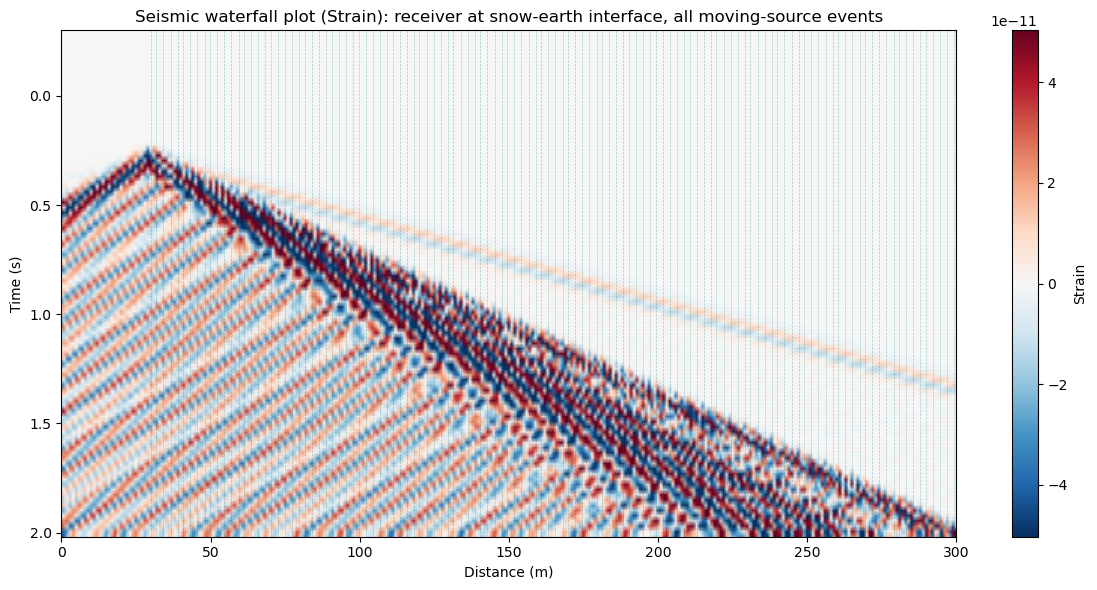

In [12]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface = 1.5

# vel_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered_dx.coords)
dims_set = set(vel_2d_layered_dx.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered_dx.dims}, coords={list(vel_2d_layered_dx.coords)}")

# Select vertical component (vy), then nearest y receiver line.
sg_vy = vel_2d_layered_dx.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vy.dims:
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vy_plot[t_name].values
x_line = sg_vy_plot[x_name].values
data = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("data shape:", data.shape)

# Clip colorscale (robust equivalent)
vmax = np.percentile(np.abs(data), 95)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    x_line,
    t_vals,
    data,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
ax.invert_yaxis()

# Mark all moving source positions
for x_src in x_positions:
    ax.axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Time (s)")
ax.set_xlim(0, 300)
ax.set_title("Seismic waterfall plot (Strain): receiver at snow-earth interface, all moving-source events")
plt.colorbar(im, ax=ax, label="Strain")
plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [13]:
# Build a combined field across all events, matching the waterfall plot logic.
vy_event = vel_2d_layered.isel({c_name: 1})
if e_name is not None and e_name in vy_event.dims:
    vy_event = vy_event.mean(dim=e_name)

# Extract raw coordinates and data the same way as static source
# vy_event dims should be (t, y, x) after transpose
vy_event = vy_event.transpose(t_name, y_name, x_name)

x_vals = vy_event[x_name].values
y_vals = vy_event[y_name].values
t_vals = vy_event[t_name].values
frames_3d = np.asarray(vy_event.values, dtype=np.float64)
frames_3d = np.nan_to_num(frames_3d, nan=0.0, posinf=0.0, neginf=0.0)

# Time subsampling starting from t=0
t_start_idx = np.searchsorted(t_vals, 0.0)
N = 1
t_idx = np.arange(t_start_idx, frames_3d.shape[0], N)

# Robust SymLogNorm scaling — same as static source
warmup = max(1, len(frames_3d) // 4)
abs_vals = np.abs(frames_3d[warmup:]).ravel()
abs_vals = abs_vals[np.isfinite(abs_vals)]
abs_vals = abs_vals[abs_vals > 1e-14]

if abs_vals.size == 0:
    vmax = 1e-8
    linthresh = 1e-10
else:
    vmax = float(np.percentile(abs_vals, 99.5))
    vmax = max(vmax, 1e-8)
    linthresh = max(float(np.percentile(abs_vals, 70)), vmax * 1e-3, 1e-10)

print("representative_event: combined over all events")
print(f"t range:        {t_vals[0]:.3f} -> {t_vals[-1]:.3f} s")
print(f"frames to anim: {len(t_idx)}")
print(f"vmax={vmax:.3e}, linthresh={linthresh:.3e}")


def run_animation():
    try:
        from matplotlib import colors
        from matplotlib import ticker

        norm = colors.SymLogNorm(
            linthresh=linthresh,
            vmin=-vmax,
            vmax=vmax,
            base=10,
        )

        # Avoid mathtext parsing issues in tick labels (especially with SymLog colorbar).
        plt.rcParams["axes.formatter.use_mathtext"] = False

        fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

        im = ax.imshow(
            frames_3d[t_idx[0]],
            extent=[x_vals.min(), x_vals.max(), y_vals.max(), y_vals.min()],
            aspect="auto",
            cmap="RdBu_r",
            norm=norm,
            origin="upper",
            interpolation="bilinear",
        )

        # Two-layer setup: snow over air.
        ax.axhline(1.5, color="black", lw=1.2, linestyle="--", label="snow-air interface (1.5 m)")

        ax.set_xlabel("x (m)")
        ax.set_ylabel("Depth (m)")
        ax.set_xlim(x_vals.min(), x_vals.max())
        ax.set_ylim(y_vals.max(), y_vals.min())
        ax.legend(loc="upper right", fontsize=8)
        cbar = plt.colorbar(im, ax=ax, label="Strain", shrink=0.8)
        cbar.formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1e}")
        cbar.update_ticks()
        title = ax.set_title(f"Wavefield Strain (all events combined) - t = {t_vals[t_idx[0]]:.4f} s")

        def update(frame_idx):
            ti = t_idx[frame_idx]
            im.set_data(frames_3d[ti])
            title.set_text(f"Wavefield Strain (all events combined) - t = {t_vals[ti]:.4f} s")
            return im, title

        ani = animation.FuncAnimation(
            fig,
            update,
            frames=len(t_idx),
            interval=120,
            blit=False,  # False for Pillow compatibility
        )

        if animation.writers.is_available("ffmpeg"):
            print("Saving with ffmpeg...", flush=True)
            writer = animation.FFMpegWriter(
                fps=30, codec="libx264",
                extra_args=["-pix_fmt", "yuv420p"],
            )
            output_name = "wavefield_2d_moving.mp4"
        else:
            print("Saving GIF with pillow...", flush=True)
            writer = animation.PillowWriter(fps=10)
            output_name = "wavefield_2d_moving_slight_subrayleigh_mom_x.gif"

        ani.save(
            output_name,
            writer=writer,
            dpi=120,
            progress_callback=lambda i, n: print(
                f"  saving frame {i}/{n}", flush=True
            ) if i % 50 == 0 else None,
        )
        plt.close(fig)
        print(f"Done! Saved as {output_name}", flush=True)
    except Exception as exc:
        import traceback
        print(f"Animation failed: {exc}", flush=True)
        traceback.print_exc()


thread = threading.Thread(target=run_animation)
thread.start()
print("Animation running in background thread.")
print("Check progress with: thread.is_alive()")

representative_event: combined over all events
t range:        -0.300 -> 2.019 s
frames to anim: 85
vmax=1.000e-08, linthresh=1.000e-10
Animation running in background thread.
Check progress with: thread.is_alive()


Saving GIF with pillow...


Sampling frequency: 41.8 Hz
Nyquist frequency:  20.9 Hz
t_vals[0]=-0.3000  t_vals[-1]=1.9952  n=97
  saving frame 0/85


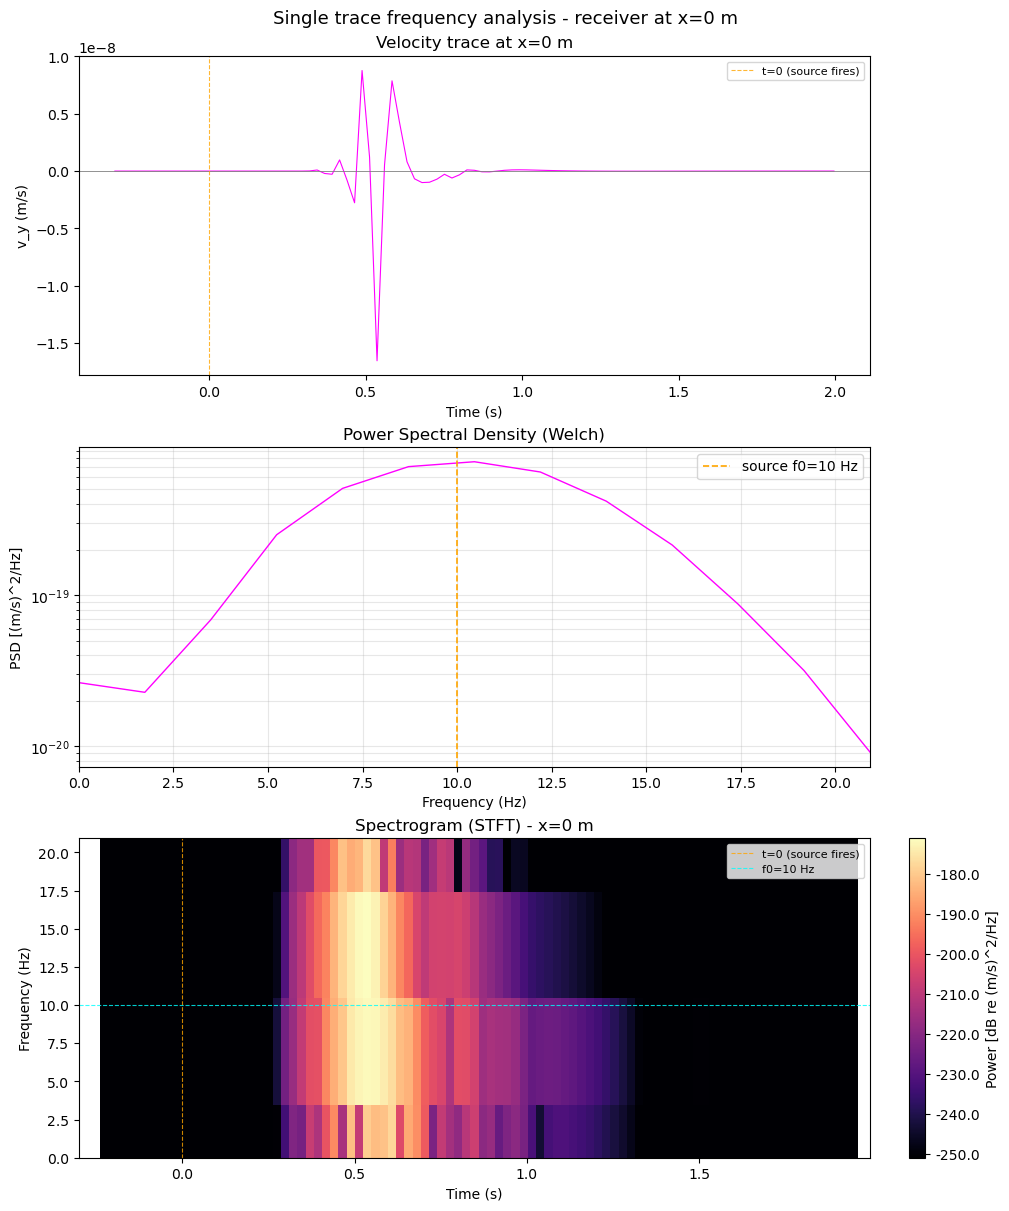

In [14]:
# Extract a single receiver trace for frequency analysis.
from matplotlib import ticker

# Disable mathtext tick-label rendering to avoid parser crashes with Agg backend.
plt.rcParams["axes.formatter.use_mathtext"] = False
plt.rcParams["text.usetex"] = False

trace_source = sg_vy
if "event_index" in trace_source.dims:
    representative_event = int(np.argmin(np.abs(x_positions - 0.0)))
    trace_source = trace_source.isel(event_index=representative_event)

trace_dim = next((d for d in ["x", "point"] if d in trace_source.dims), None)
if trace_dim is None:
    raise ValueError(f"Could not find a receiver coordinate in dims={trace_source.dims}")

# FIX 1: slice from -0.3 to capture pre-signal and align t=0 correctly
trace = trace_source.sel({trace_dim: 0.0}, method="nearest").sel(t=slice(-0.3, 2.0))
t_vals = trace.t.values
y_vals = trace.values

dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")
print(f"t_vals[0]={t_vals[0]:.4f}  t_vals[-1]={t_vals[-1]:.4f}  n={len(t_vals)}")

fig, axes = plt.subplots(3, 1, figsize=(10, 12), constrained_layout=True)

# 1) Raw signed velocity trace
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].axhline(0, color="gray", lw=0.6)
# FIX 2: mark t=0 (source fires) on the trace too
axes[0].axvline(0, color="orange", lw=0.8, linestyle="--", alpha=0.8, label="t=0 (source fires)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("v_y (m/s)")
axes[0].set_title("Velocity trace at x=0 m")
axes[0].legend(fontsize=8)

# 2) Power Spectral Density (Welch)
nperseg = min(1024, len(y_vals) // 4)
freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
axes[1].semilogy(freqs_psd, psd, color="magenta", lw=1.0)
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, min(100, fs / 2))
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# 3) Spectrogram (STFT)
nperseg_stft = min(256, len(y_vals) // 16)
nperseg_stft = max(nperseg_stft, int(fs * 0.05))  # at least 50ms window

freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 15 // 16,
    window="hann",
    scaling="density",
)

# FIX 3: shift t_stft by the actual trace start (now -0.3s, not 0.0)
t_stft = t_stft + t_vals[0]

Sxx_db = 10 * np.log10(Sxx + 1e-40)
vmax = Sxx_db.max()
vmin = vmax - 80  # 80 dB dynamic range

im = axes[2].pcolormesh(
    t_stft,
    freqs_stft,
    Sxx_db,
    shading="auto",
    cmap="magma",
    vmin=vmin,
    vmax=vmax,
)
axes[2].set_xlim(t_vals[0], t_vals[-1])
# FIX 4: axvline at t=0 (source fires), not at t_vals[0]
axes[2].axvline(0, color="orange", lw=0.8, linestyle="--", alpha=0.8, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.8, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) - x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))
axes[2].legend(loc="upper right", fontsize=8)
cbar = fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")
cbar.formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1f}")
cbar.update_ticks()

# Apply plain scalar formatters only where axes are linear.
scalar_fmt = ticker.ScalarFormatter(useMathText=False)
scalar_fmt.set_scientific(False)
axes[0].xaxis.set_major_formatter(scalar_fmt)
axes[0].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=False))
axes[2].xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=False))
axes[2].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=False))

plt.suptitle("Single trace frequency analysis - receiver at x=0 m", fontsize=13)

from IPython.display import display
display(fig)
plt.close(fig)

In [ ]:
# Inspect files for one failed event directory.
from pathlib import Path

sim_name = moving_source_simulation_names[0]
event_name = moving_source_event_names[0]
out_dir = Path(p.simulations.get_simulation_output_directory(sim_name, event_name))
print("Inspecting:", out_dir)

for path in sorted(out_dir.rglob("*")):
    rel = path.relative_to(out_dir)
    if rel.parts and rel.parts[0] in {"AUXILIARY", "CHECKPOINTS", "META"}:
        continue
    print(rel)
    if path.is_file() and path.name.lower() in {"stdout", "stderr", "status", "meta.json", "simulation.log", "log", "run_job.sh"}:
        try:
            lines = path.read_text(errors="ignore").splitlines()
            print("--- tail", rel, "---")
            for line in lines[-30:]:
                print(line)
        except Exception as exc:
            print("Could not read", rel, exc)

print("Done.")

Inspecting: simulation_wavefield_moving_source_moment_slight_subrayleigh_x/EVENTS/event_wavefield_output_x000/WAVEFORM_DATA/INTERNAL/f5/14/041412dc0354
job_info.json
meta.json
--- tail meta.json ---
                    }
                ],
                "courant_number": 0.6,
                "end_time_in_seconds": 2.0,
                "point_source": [
                    {
                        "location": [
                            30.0,
                            2.5
                        ],
                        "source_time_function": {
                            "center_frequency": 10.0,
                            "time_shift_in_seconds": 0.3,
                            "wavelet": "ricker"
                        },
                        "spatial_type": "moment_tensor",
                        "spatial_weights": [
                            1.0,
                            0.0,
                            0.0
                        ]
                    }
     

  saving frame 50/85
Animation failed: index 97 is out of bounds for axis 0 with size 97


Traceback (most recent call last):
  File "/tmp/ipykernel_1518300/3980354832.py", line 107, in run_animation
    ani.save(
  File "/home/sbachmann/miniforge3/envs/salvus/lib/python3.11/site-packages/matplotlib/animation.py", line 1122, in save
    anim._draw_next_frame(d, blit=False)
  File "/home/sbachmann/miniforge3/envs/salvus/lib/python3.11/site-packages/matplotlib/animation.py", line 1157, in _draw_next_frame
    self._draw_frame(framedata)
  File "/home/sbachmann/miniforge3/envs/salvus/lib/python3.11/site-packages/matplotlib/animation.py", line 1789, in _draw_frame
    self._drawn_artists = self._func(framedata, *self._args)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1518300/3980354832.py", line 84, in update
    title.set_text(f"Wavefield Strain (all events combined) - t = {t_vals[ti]:.4f} s")
                                                                   ~~~~~~^^^^
IndexError: index 97 is out of bounds for axis 0 with size 97
